In [21]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import os
import shutil

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, AveragePooling2D 

from tensorflow.keras.callbacks import EarlyStopping 
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from tensorflow.keras.layers import BatchNormalization  
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_df = pd.read_csv("train.csv")

train_df.head()

,image_names,emergency_or_not
0,1503.jpg,0
1,1420.jpg,0
2,1764.jpg,0
3,1356.jpg,0
4,1117.jpg,0


In [10]:
#create directories 
os.makedirs("dataset/emergency", exist_ok=True)
os.makedirs("dataset/non_emergency", exist_ok=True)

#Images source
source_folder = "train"

for index, row in train_df.iterrows():

    image_name = row['image_names']
    label = row['emergency_or_not']

#Create the full path to the image file.
    source_path = os.path.join(source_folder, image_name)

    # file paths for emergency and non-emergency
    if label == 0:
        destination_path = os.path.join("dataset/emergency", image_name)
    else:
        destination_path = os.path.join("dataset/non_emergency", image_name)

    # Copy image
    shutil.copy(source_path, destination_path)

print("Images organised successfully!")

Images organised successfully!


In [11]:
#import the images
data_dir = "dataset"

train_ds = image_dataset_from_directory(data_dir,validation_split=0.1,subset="training",seed=42,batch_size=None)

test_ds = image_dataset_from_directory(data_dir,validation_split=0.1,subset="validation",seed=42,batch_size=None)

print(train_ds.class_names)

Found 1646 files belonging to 2 classes.
Using 1482 files for training.
Found 1646 files belonging to 2 classes.
Using 164 files for validation.
['emergency', 'non_emergency']


In [12]:
# Extract training data
x_train = []
y_train = []

for x, y in train_ds:
    x_train.append(np.uint8(x.numpy()))
    y_train.append(y.numpy())

x_train = np.array(x_train)
y_train = np.array(y_train)


# Extract testing data

x_test = []
y_test = []

for x, y in test_ds:
    x_test.append(np.uint8(x.numpy()))
    y_test.append(y.numpy())

x_test = np.array(x_test)
y_test = np.array(y_test)

In [13]:
print(x_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)

(1482, 256, 256, 3)
(1482,)
(164, 256, 256, 3)
(164,)


(-0.5, 255.5, 255.5, -0.5)

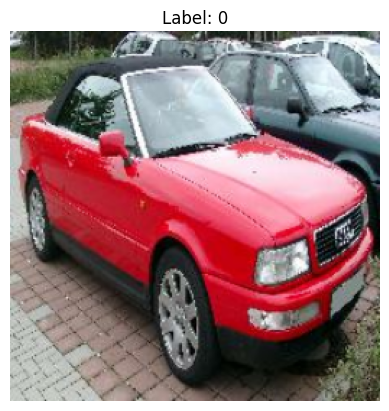

In [14]:
#plot first image
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")

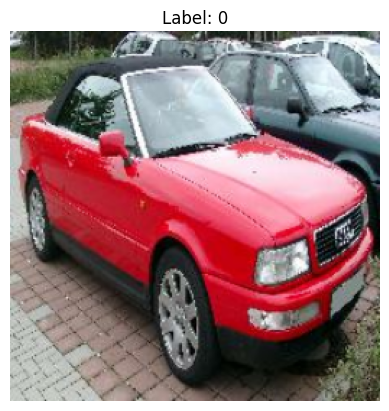

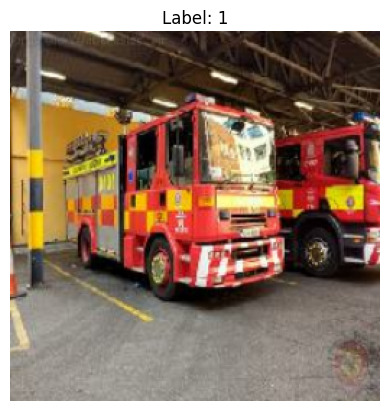

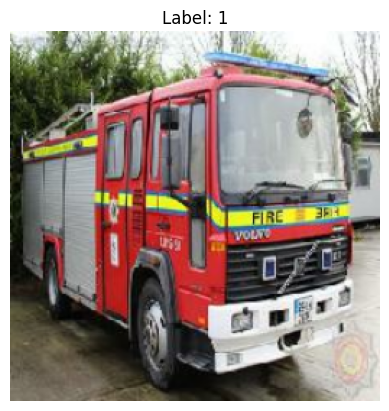

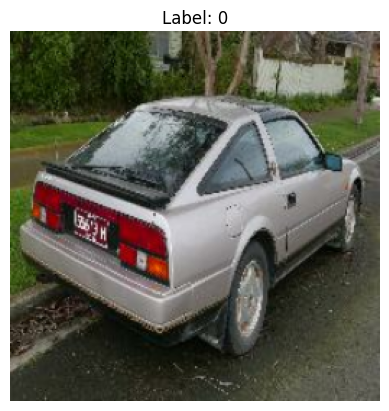

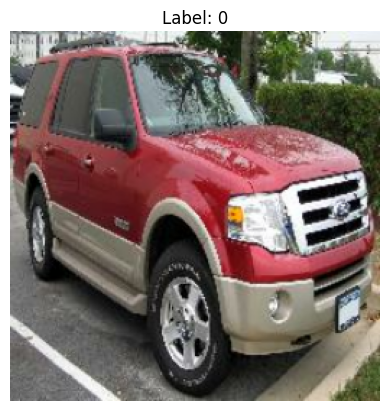

In [15]:
#to see the first five images
for i in range(5):
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
    plt.show()

In [16]:
#normalize
# divide the x_train and x_test arrays by 255.
x_train = x_train / 255
x_test = x_test / 255

width_npix = x_train.shape[1]
height_npix = x_train.shape[2]

### Data Argumentation

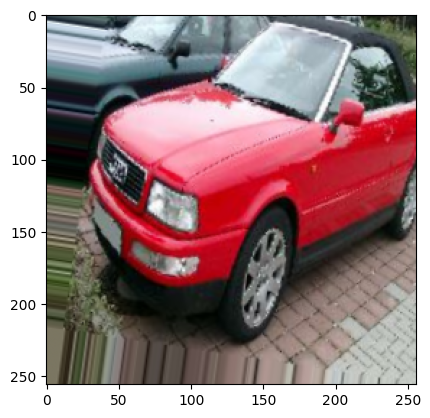

In [20]:
train_datagen = ImageDataGenerator(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1, 
                                   horizontal_flip=True, vertical_flip=False, shear_range=0.10, zoom_range=0.10, validation_split=0.2)
train_datagen.fit(x_train) 

#create a randomly transformed image
new_image = train_datagen.random_transform(x_train[0]) 

#plot the image
plt.imshow(new_image, cmap = "gray")

c:\Users\ADMIN\anaconda3\envs\sql_packages\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,481,985 (32.36 MB)

 Trainable params: 8,481,985 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\ADMIN\anaconda3\envs\sql_packages\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


38/38 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5382 - loss: 0.9477 - val_accuracy: 0.6216 - val_loss: 0.7969
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7013 - loss: 0.5953 - val_accuracy: 0.7331 - val_loss: 0.5483
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7465 - loss: 0.5399 - val_accuracy: 0.7568 - val_loss: 0.5312
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7470 - loss: 0.5348 - val_accuracy: 0.7230 - val_loss: 0.5211
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7471 - loss: 0.5150 - val_accuracy: 0.6993 - val_loss: 0.5520
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7573 - loss: 0.4950 - val_accuracy: 0.7196 - val_loss: 0.6341
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.7690 - loss: 0.5129 - val_accuracy: 0.7601 - val_loss: 0.5363
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7543 - loss: 0.4932 - val_accuracy: 0.8074 - val_loss: 0.4744
Epo

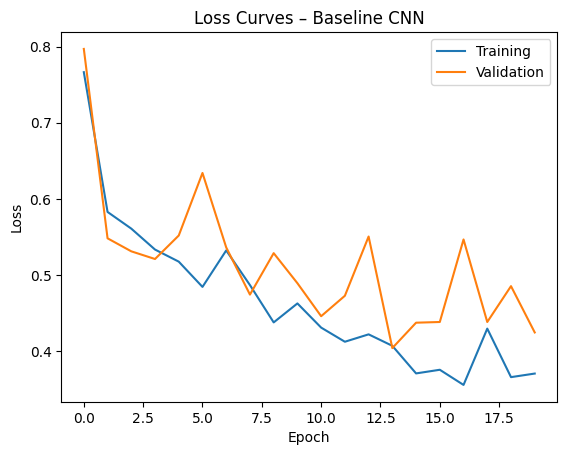

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 348ms/step
      Metric     Score
0   Accuracy  0.829268
1  Precision  0.884615
2     Recall  0.676471


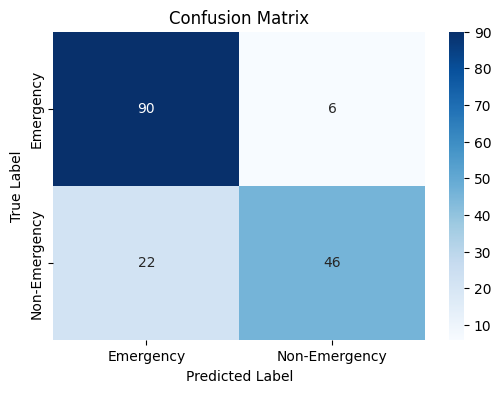

In [22]:
model = Sequential()

#CONVOLUTION BLOCK 1(first hidden layer)
#add first convolutional layer
model.add(Conv2D(filters = 32, kernel_size = (3, 3),padding="same", input_shape = (width_npix, height_npix, 3), activation = 'relu')) 

#add pooling layer
model.add(MaxPooling2D(pool_size = (2, 2), padding="same")) 

#CONVOLUTION BLOCK 2
#second convolution layer 
model.add(Conv2D(filters = 64, kernel_size = (3, 3),padding="same", activation = 'relu')) 

#pooling layer 
model.add(MaxPooling2D(pool_size = (2, 2), padding="same"))

#CONVOLUTION BLOCK 3
#third convolution layer
model.add(Conv2D(filters = 128, kernel_size = (3, 3),padding="same", activation = 'relu')) 

#pooling layer 
model.add(MaxPooling2D(pool_size = (2, 2), padding="same"))

#add flatten layer(make it 1D)
model.add(Flatten())

#add layer
model.add(Dense(64, activation = 'relu'))

#add ouput layer
model.add(Dense(1, activation = 'sigmoid'))

model.summary()


model.compile(optimizer=Adam(),loss="binary_crossentropy",metrics=["accuracy"])

batch_size = 32

history = model.fit(train_datagen.flow(x_train,y_train,batch_size=batch_size,subset="training"),epochs=20,
                    validation_data=train_datagen.flow(x_train,y_train,batch_size=batch_size,subset="validation"))

#Plot the loss
history_df = pd.DataFrame(history.history) 
plt.plot(history_df["loss"], label = "Training") 
plt.plot(history_df["val_loss"], label = "Validation")
plt.title("Loss Curves – Baseline CNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Predict probabilities
y_prob = model.predict(x_test)


y_pred = (y_prob >= 0.5).astype(int)

#evaluate model performance
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
 
results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall"],
    "Score": [accuracy, precision, recall]
})

print(results_df)

#plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Emergency", "Non-Emergency"],yticklabels=["Emergency", "Non-Emergency"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()